# 05 — Rating-Change Summen

Zentrale Kennzahl: **Summe von `rating_change_weighted`** pro Spieler.

1. Pro Kalenderjahr
2. Gesamt (2015 – aktuellstes Datum)
3. Gesamt-Aufteilung nach
   - **A** Gegner-Geschlecht (Mann / Frau / unbekannt)
   - **B** Eigene Farbe (Weiß / Schwarz)
   - **C** Relativer Stärke-Bucket: gleich (±50), stärker (>+50), schwächer (<−50)

Filter: nur Spieler mit `active = TRUE AND analysis_group IS NOT NULL`.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd()))
from _setup import load_query, apply_style, GROUP_PALETTE, GROUP_ORDER

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

apply_style()

## Datenbasis laden

Ein gemeinsamer DataFrame, in dem jede Partie mit eigenem Rating, Gegner-Geschlecht und Stärke-Bucket angereichert ist. Eine Partie ohne `opponent_fide_id` → `opponent_sex = 'unknown'`.

In [2]:
sql = '''
SELECT
    gr.fide_id,
    gr.period,
    EXTRACT(YEAR FROM gr.period)::int AS year,
    gr.rating_change_weighted,
    gr.color,
    gr.opponent_rating,
    rh.std_rating AS own_rating,
    p.analysis_group,
    COALESCE(opp.sex, 'unknown') AS opponent_sex
FROM game_results gr
JOIN players p ON p.fide_id = gr.fide_id
LEFT JOIN rating_history rh ON rh.fide_id = gr.fide_id AND rh.period = gr.period
LEFT JOIN players opp ON opp.fide_id = gr.opponent_fide_id
WHERE p.active = TRUE AND p.analysis_group IS NOT NULL
'''
df = load_query(sql)
df['rating_change_weighted'] = df['rating_change_weighted'].astype(float)
df['own_rating'] = pd.to_numeric(df['own_rating'], errors='coerce')
df['opponent_rating'] = pd.to_numeric(df['opponent_rating'], errors='coerce')
df['diff'] = df['opponent_rating'] - df['own_rating']

def strength_bucket(d):
    if pd.isna(d):
        return 'unknown'
    if d > 50:
        return 'stärker'
    if d < -50:
        return 'schwächer'
    return 'gleich'
df['strength'] = df['diff'].apply(strength_bucket)
print('Partien:', len(df))
df.head()

Partien: 153528


,fide_id,period,year,rating_change_weighted,color,opponent_rating,own_rating,analysis_group,opponent_sex,diff,strength
0,24171760,2025-04-01,2025,-1.8,B,2374,2508.0,female_top,unknown,-134.0,schwächer
1,121576,2020-01-01,2020,-6.9,W,2381,2520.0,male_control,unknown,-139.0,schwächer
2,121576,2020-01-01,2020,1.5,B,2221,2520.0,male_control,unknown,-299.0,schwächer
3,105198,2020-01-01,2020,0.8,W,2081,2481.0,male_control,unknown,-400.0,schwächer
4,121576,2020-01-01,2020,-7.1,B,2365,2520.0,male_control,unknown,-155.0,schwächer


## 1. Jahres-Summen pro Spieler

Für die Detailtabelle pro Spieler siehe Notebook 06. Hier: Ø-Jahressumme pro Gruppe + Boxplot.

In [3]:
yearly = (
    df.groupby(['analysis_group', 'fide_id', 'year'])['rating_change_weighted']
      .sum().reset_index(name='yearly_sum')
)
yearly_group = (
    yearly.groupby(['analysis_group', 'year'])['yearly_sum']
          .agg(['mean', 'median', 'count'])
          .round(1).reset_index()
)
yearly_group.pivot(index='year', columns='analysis_group', values='mean')

analysis_group,female_top,male_control
year,,
2015,29.6,45.8
2016,19.7,41.1
2017,54.8,37.7
2018,42.4,30.5
2019,28.2,22.9
2020,25.4,18.5
2021,25.2,16.1
2022,19.6,16.1
2023,12.1,3.8


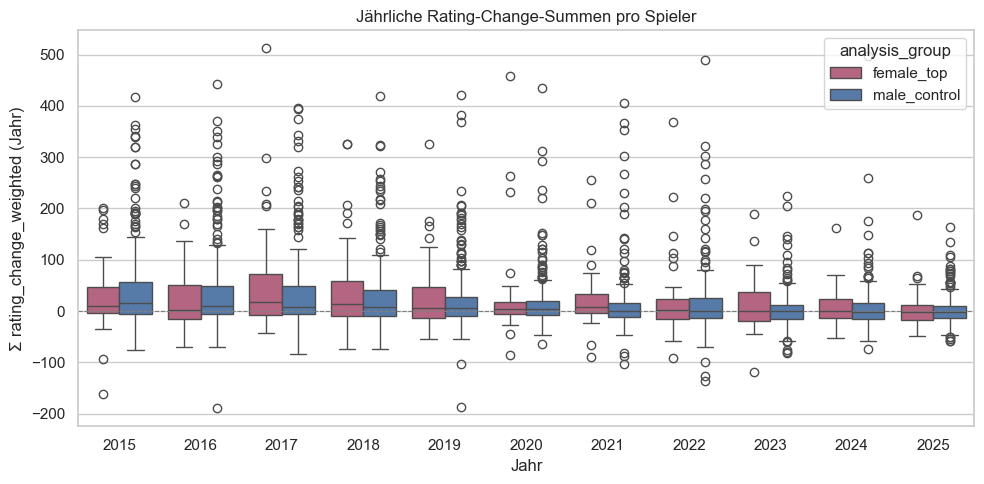

In [4]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(
    data=yearly, x='year', y='yearly_sum',
    hue='analysis_group', hue_order=GROUP_ORDER, palette=GROUP_PALETTE, ax=ax,
)
ax.axhline(0, color='grey', lw=0.8, ls='--')
ax.set_ylabel('Σ rating_change_weighted (Jahr)')
ax.set_xlabel('Jahr')
ax.set_title('Jährliche Rating-Change-Summen pro Spieler')
plt.tight_layout(); plt.show()

## 2. Gesamtsumme pro Spieler

Summe über den gesamten beobachteten Zeitraum (abhängig vom aktuellen Backfill-Stand).

In [5]:
total = (
    df.groupby(['analysis_group', 'fide_id'])['rating_change_weighted']
      .sum().reset_index(name='total_sum')
)
total.groupby('analysis_group').agg(
    n_players=('fide_id', 'nunique'),
    mean_total=('total_sum', 'mean'),
    median_total=('total_sum', 'median'),
    min_total=('total_sum', 'min'),
    max_total=('total_sum', 'max'),
).round(1)

,n_players,mean_total,median_total,min_total,max_total
analysis_group,,,,,
female_top,43,258.0,44.8,-125.9,1385.8
male_control,235,221.0,28.3,-209.5,1363.1


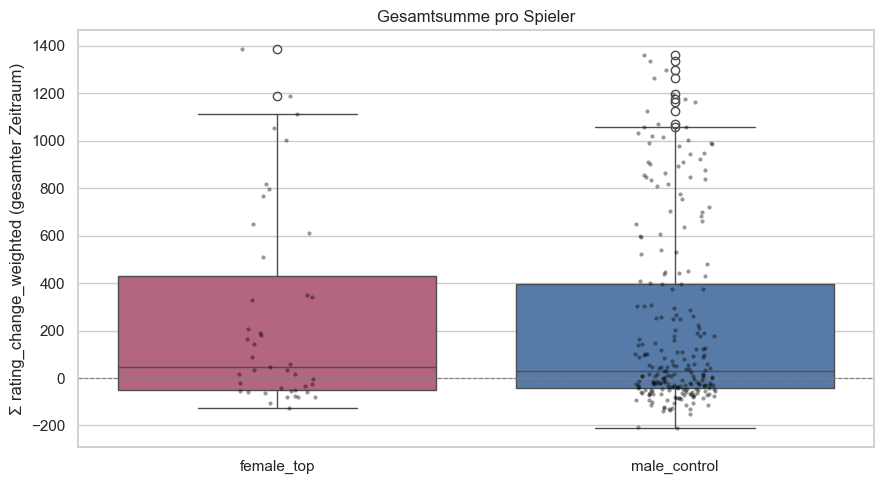

In [6]:
fig, ax = plt.subplots()
sns.boxplot(
    data=total, x='analysis_group', y='total_sum',
    hue='analysis_group', order=GROUP_ORDER, palette=GROUP_PALETTE,
    legend=False, ax=ax,
)
sns.stripplot(
    data=total, x='analysis_group', y='total_sum',
    order=GROUP_ORDER, color='black', alpha=0.4, size=3, ax=ax,
)
ax.axhline(0, color='grey', lw=0.8, ls='--')
ax.set_ylabel('Σ rating_change_weighted (gesamter Zeitraum)')
ax.set_xlabel('')
ax.set_title('Gesamtsumme pro Spieler')
plt.tight_layout(); plt.show()

## 3A. Aufteilung nach Gegner-Geschlecht

Anmerkung: ~12–16 % der Partien haben noch keine `opponent_fide_id` (Namensvarianten, v.a. indische Spieler) und werden als `unknown` gezählt.

In [7]:
split_sex = (
    df.groupby(['analysis_group', 'fide_id', 'opponent_sex'])['rating_change_weighted']
      .sum().reset_index(name='sum')
)
split_sex_group = split_sex.groupby(['analysis_group', 'opponent_sex']).agg(
    mean=('sum', 'mean'), median=('sum', 'median'), n_players=('fide_id', 'nunique'),
).round(1).reset_index()
split_sex_group

,analysis_group,opponent_sex,mean,median,n_players
0,female_top,F,94.6,11.8,43
1,female_top,M,132.8,38.7,43
2,female_top,unknown,30.5,5.0,43
3,male_control,F,14.4,2.3,231
4,male_control,M,194.5,33.5,235
5,male_control,unknown,12.4,-1.4,234


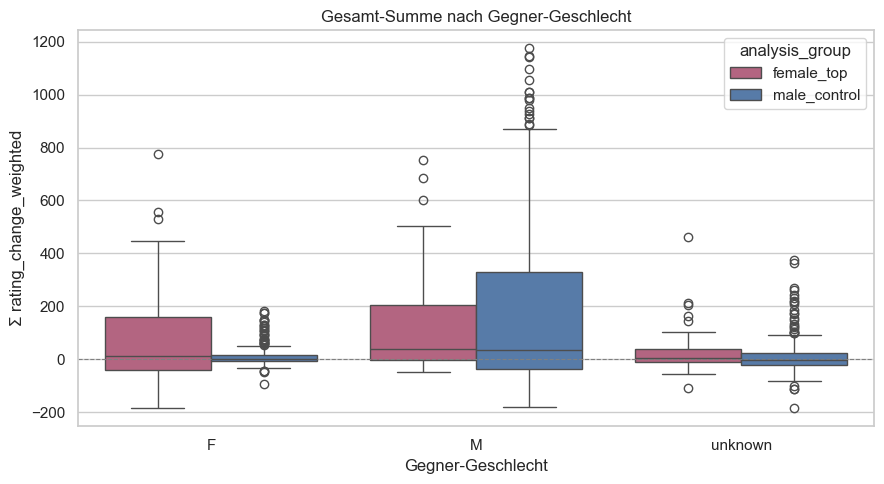

In [8]:
fig, ax = plt.subplots()
sns.boxplot(
    data=split_sex, x='opponent_sex', y='sum',
    hue='analysis_group', hue_order=GROUP_ORDER, palette=GROUP_PALETTE,
    order=['F', 'M', 'unknown'], ax=ax,
)
ax.axhline(0, color='grey', lw=0.8, ls='--')
ax.set_ylabel('Σ rating_change_weighted')
ax.set_xlabel('Gegner-Geschlecht')
ax.set_title('Gesamt-Summe nach Gegner-Geschlecht')
plt.tight_layout(); plt.show()

## 3B. Aufteilung nach eigener Farbe

In [9]:
split_color = (
    df.dropna(subset=['color'])
      .groupby(['analysis_group', 'fide_id', 'color'])['rating_change_weighted']
      .sum().reset_index(name='sum')
)
split_color.groupby(['analysis_group', 'color']).agg(
    mean=('sum', 'mean'), median=('sum', 'median'), n_players=('fide_id', 'nunique'),
).round(1)

mean  median  n_players
analysis_group color                          
female_top     B      -66.3   -87.7         43
               W      324.3   156.3         43
male_control   B      -45.5   -62.4        235
               W      266.5   131.9        235

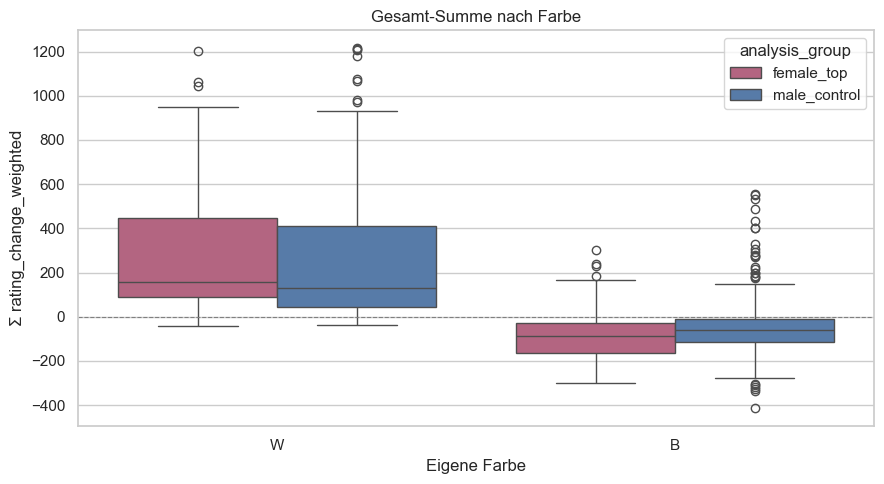

In [10]:
fig, ax = plt.subplots()
sns.boxplot(
    data=split_color, x='color', y='sum',
    hue='analysis_group', hue_order=GROUP_ORDER, palette=GROUP_PALETTE,
    order=['W', 'B'], ax=ax,
)
ax.axhline(0, color='grey', lw=0.8, ls='--')
ax.set_ylabel('Σ rating_change_weighted')
ax.set_xlabel('Eigene Farbe')
ax.set_title('Gesamt-Summe nach Farbe')
plt.tight_layout(); plt.show()

## 3C. Aufteilung nach Gegnerstärke (relativ)

- **gleich:** |Gegner − ich| ≤ 50
- **stärker:** Gegner > ich + 50
- **schwächer:** Gegner < ich − 50

Partien ohne eigenes Rating in `rating_history` fallen in `unknown`.

In [11]:
split_strength = (
    df.groupby(['analysis_group', 'fide_id', 'strength'])['rating_change_weighted']
      .sum().reset_index(name='sum')
)
split_strength.groupby(['analysis_group', 'strength']).agg(
    mean=('sum', 'mean'), median=('sum', 'median'), n_players=('fide_id', 'nunique'),
).round(1)

mean  median  n_players
analysis_group strength                           
female_top     gleich      55.1    32.1         43
               schwächer  -78.8   -58.8         43
               stärker    281.7    50.2         43
               unknown      0.0     0.0          5
male_control   gleich      35.7    13.1        233
               schwächer  -56.4   -29.3        235
               stärker    245.2    39.3        232
               unknown      0.0     0.0         25

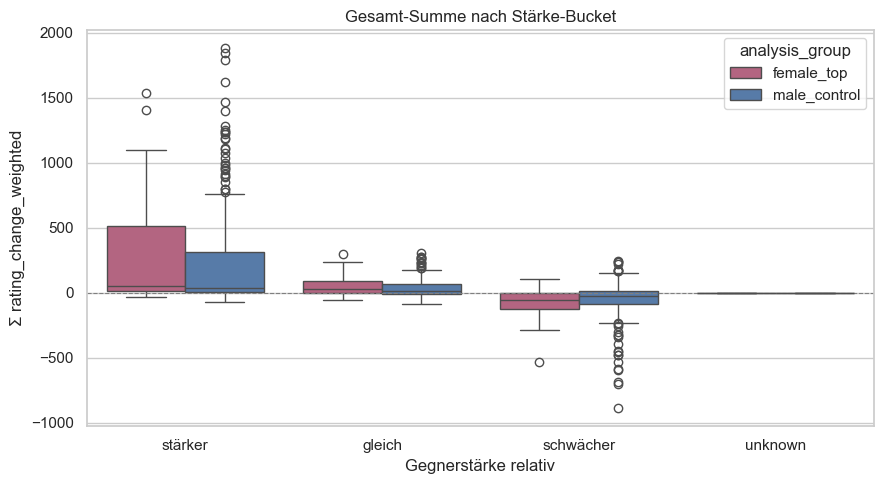

In [12]:
strength_order = ['stärker', 'gleich', 'schwächer', 'unknown']
# drop empty categories
strength_order = [s for s in strength_order if s in split_strength['strength'].unique()]
fig, ax = plt.subplots()
sns.boxplot(
    data=split_strength, x='strength', y='sum',
    hue='analysis_group', hue_order=GROUP_ORDER, palette=GROUP_PALETTE,
    order=strength_order, ax=ax,
)
ax.axhline(0, color='grey', lw=0.8, ls='--')
ax.set_ylabel('Σ rating_change_weighted')
ax.set_xlabel('Gegnerstärke relativ')
ax.set_title('Gesamt-Summe nach Stärke-Bucket')
plt.tight_layout(); plt.show()

## Partienanzahl pro Bucket (Plausibilitätscheck)

Damit die Summen im Kontext stehen: wie viele Partien gehen in jede Kategorie ein?

In [13]:
counts = (
    df.groupby(['analysis_group', 'opponent_sex', 'color', 'strength']).size()
      .reset_index(name='n_games')
)
counts.groupby('analysis_group')['n_games'].sum().to_frame('total_games')

,total_games
analysis_group,
female_top,27990
male_control,125537
